In [13]:
import numpy as np 
import pandas as pd
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2

from ink_dataset import InkDetectionDataset
from ink_detection_net import InkDetectionNet
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from inference_data_manager import InferenceDataManager

In [7]:
# --- INITIALIZATIONS ---

TRAIN_SPLIT_DIR = Path("/Volumes/ZX20/eliva-26-ink-detection/train")
fragment_ids = [d.name for d in Path(TRAIN_SPLIT_DIR).iterdir() if d.is_dir()]
test_fragments = fragment_ids[:3]

# Initialize a Dataset with only a few fragments for testing
dataset = InkDetectionDataset(
    fragment_ids=test_fragments,
    data_dir=TRAIN_SPLIT_DIR,
    patch_size=256,
    slice_range=(0, 64),
    samples_per_epoch=10, # Small number for testing
    ink_prob=0.8 # High probability of ink for visualization
)

loader = DataLoader(dataset, batch_size=1, shuffle=True)

Initializing Dataset and indexing ink coordinates...
Fragment p_0s2t5eg93al2: 100037 ink pixels, 512013 papyrus pixels indexed.
Fragment p_11502d5ne53i: 408206 ink pixels, 2420608 papyrus pixels indexed.
Fragment p_1x2q1icnrxsu: 167451 ink pixels, 902263 papyrus pixels indexed.


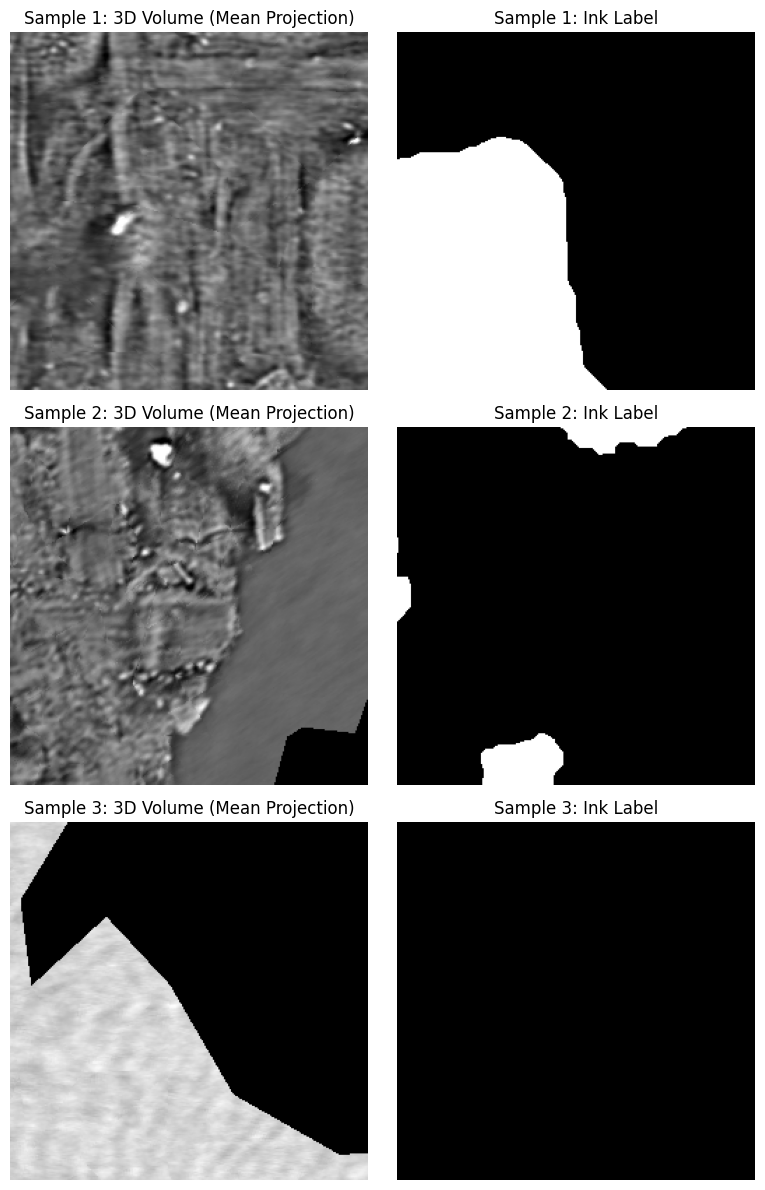

In [8]:
# Extract and Plot 3 samples
fig, axes = plt.subplots(3, 2, figsize=(8, 12))
    
for i, (volume, label) in enumerate(loader):
    if i >= 3: break
        
    # volume shape: [Batch, Slices, H, W] -> [1, 25, 256, 256]
    # label shape: [Batch, 1, H, W] -> [1, 1, 256, 256]
        
    # To visualize the 3D volume on a 2D screen, we can:
    # a) Take the first slice
    vol_img = volume[0, 0].numpy()  
    lbl_img = label[0, 0].numpy()
        
    # Plot Volume
    axes[i, 0].imshow(vol_img, cmap='gray')
    axes[i, 0].set_title(f"Sample {i+1}: 3D Volume (Mean Projection)")
    axes[i, 0].axis('off')
    
    # Plot Label
    axes[i, 1].imshow(lbl_img, cmap='gray')
    axes[i, 1].set_title(f"Sample {i+1}: Ink Label")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Econding Test 

model = InkDetectionNet(input_channels=64)

for i, (volume, label) in enumerate(loader):
    if i >= 3: break
    
    x, features = model.encoder(volume)
    print(f"Sample {i+1} - Encoder Output Shape: {x.shape}")
    
    # print the first feature map for visualization
    feature_map = x[0][123].detach().numpy()  # Take the first feature map of the first sample
    print(feature_map)
        
    


Sample 1 - Encoder Output Shape: torch.Size([1, 2048, 8, 8])
[[0.        0.        0.        0.        0.        0.        0.
  0.       ]
 [0.        0.        0.6280458 0.        0.        0.        0.
  0.       ]
 [0.        0.        0.        0.        0.        0.        0.
  0.       ]
 [0.        0.        0.        0.        0.        0.        0.
  0.       ]
 [0.        0.        0.        0.        0.        0.        0.
  0.       ]
 [0.        0.        0.        0.        0.        0.        0.
  0.       ]
 [0.        0.        0.        0.        0.        0.        0.
  0.       ]
 [0.        0.        0.        0.        0.        0.        0.
  0.       ]]
Sample 2 - Encoder Output Shape: torch.Size([1, 2048, 8, 8])
[[0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        

Sample 1 - Inference Output Shape: torch.Size([1, 1, 256, 256])
Sample 2 - Inference Output Shape: torch.Size([1, 1, 256, 256])
Sample 3 - Inference Output Shape: torch.Size([1, 1, 256, 256])


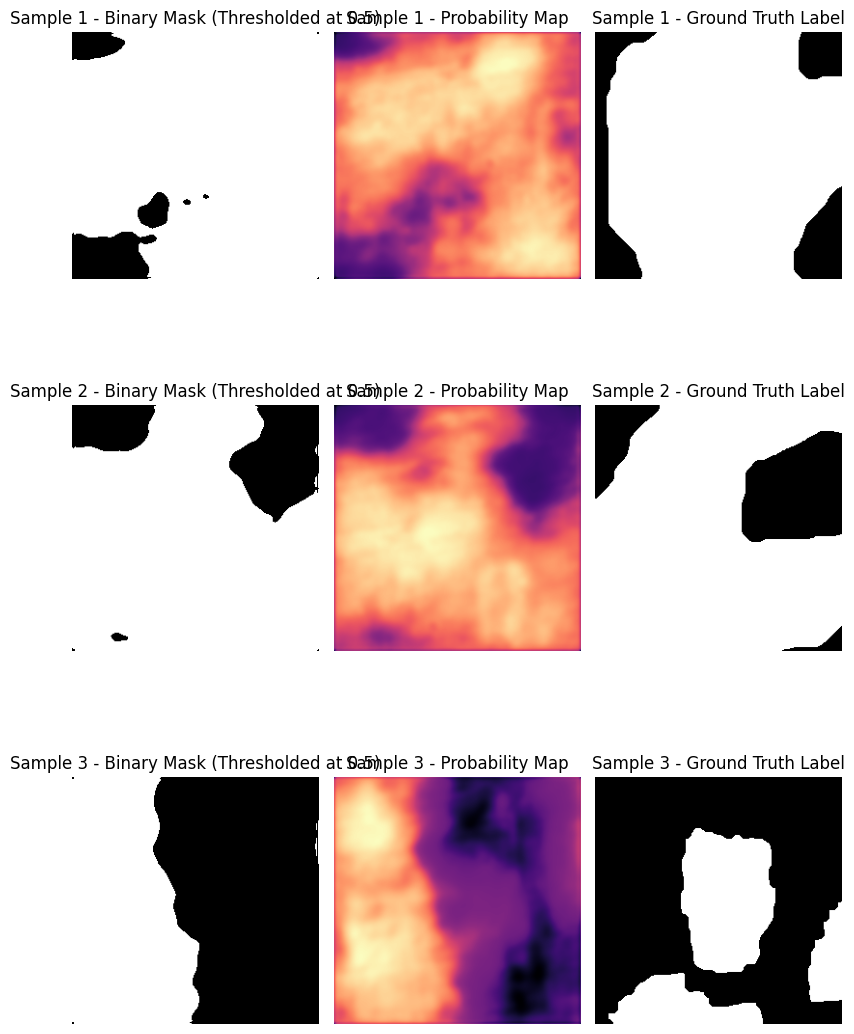

In [11]:
# Inference Test

model = InkDetectionNet(input_channels=64)
checkpoint = torch.load("./checkpoints/best_ink_model.pth", map_location="cpu")
# load weights 
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # Set model to evaluation mode


fig, axes = plt.subplots(3, 3, figsize=(8, 12))

for i, (volume, label) in enumerate(loader):
    if i >= 3: break
    
    with torch.no_grad():
        output = model.predict(volume)  # Get the output from the model (already applies sigmoid)
    
    print(f"Sample {i+1} - Inference Output Shape: {output.shape}")
    
    # Visualize the probability map for the first sample in the batch
    output_img = output[0, 0].numpy() 
    
    # binary mask for visualization (threshold at 0.5)
    binary_mask = (output_img > 0.5).astype(np.uint8) * 255
    
    
    # Plot the binary mask
    axes[i, 0].imshow(binary_mask, cmap='gray')
    axes[i, 0].set_title(f"Sample {i+1} - Binary Mask (Thresholded at 0.5)")
    axes[i, 0].axis('off')
    
    # Plot the probability map
    axes[i, 1].imshow(output_img, cmap='magma')
    axes[i, 1].set_title(f"Sample {i+1} - Probability Map")
    axes[i, 1].axis('off')

    # plot the corresponding label for comparison
    label_img = label[0, 0].numpy()
    axes[i, 2].imshow(label_img, cmap='gray')
    axes[i, 2].set_title(f"Sample {i+1} - Ground Truth Label")
    axes[i, 2].axis('off')
    
    

plt.tight_layout()
plt.show()

In [ ]:

base_dir = Path("/Volumes/ZX20/eliva-26-ink-detection/train")
fragment_dirs = [d for d in base_dir.iterdir() if d.is_dir() and (d / "surface_volume").is_dir()]

for fragment_dir in fragment_dirs:
    mask_file = fragment_dir / "mask.png"
    if mask_file.exists():
        mask = np.asarray(Image.open(mask_file))
        print(f"Loaded mask for fragment: {fragment_dir.name}, shape: {mask.shape}")
        unique_values = np.unique(mask)
        if 1 not in unique_values:
            print(f"Warning: No ink pixels found in mask for fragment: {fragment_dir.name}")
        
    else:
        print(f"No mask found for fragment: {fragment_dir.name}")

Fragment p_40qtrko5ie06 loaded. Grid: 4x4 (16 patches)


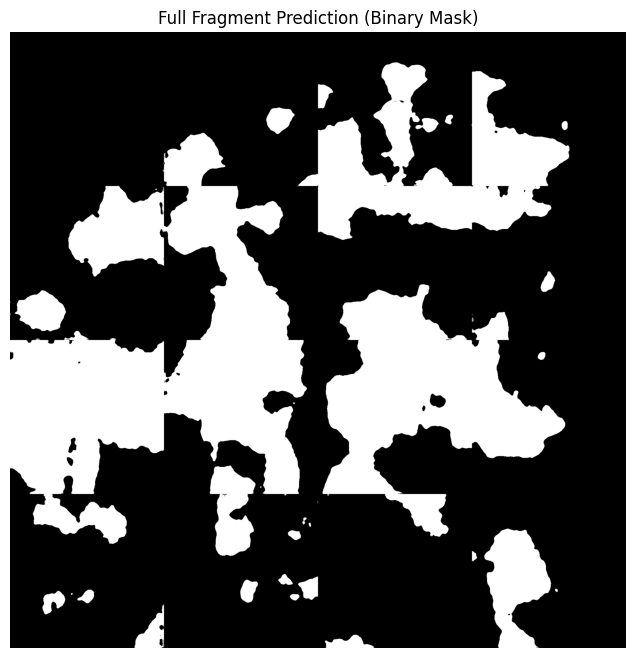

In [22]:
## Inference Test


fragment_id = "p_40qtrko5ie06"
manager = InferenceDataManager(data_dir=TRAIN_SPLIT_DIR, patch_size=512, slices=(0, 64))
manager.set_fragment(fragment_id)

# initialize an empty map to store the predictions for the entire fragment
full_map = np.zeros(manager.image_shape)

for i in range(len(manager)):
    patch, (y, x) = manager.get_patch(i)
    patch_tensor = torch.from_numpy(patch).unsqueeze(0)  # Add batch dimension
    with torch.no_grad():
        output = model.predict(patch_tensor)  # Get the output from the model (already applies sigmoid)
    output_img = output[0, 0].numpy()  # Get the predicted probability map for the patch
    
    # binary mask (threshold at 0.7)
    output_img = (output_img > 0.5).astype(np.float32)
    
    full_map[y:y+manager.patch_size, x:x+manager.patch_size] = output_img  # Place the patch prediction in the full map
    
# Visualize the full binary map for the fragment
plt.figure(figsize=(8, 8))
plt.imshow(full_map, cmap='gray')
plt.title("Full Fragment Prediction (Binary Mask)")
plt.axis('off')
plt.show()
